Imports and setup

In [83]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier


Getting data from 2010 to 2026

In [84]:
spy = yf.download("SPY", start="2010-01-01", end="2026-07-15")

spy = spy[['Close', 'Volume']]
spy['Returns'] = spy['Close'].pct_change()
spy['Volatility'] = spy['Returns'].rolling(20).std()
spy.dropna(inplace=True)


/tmp/ipykernel_809/2242013902.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download("SPY", start="2010-01-01", end="2026-07-15")
[*********************100%***********************]  1 of 1 completed


Walk-forward validation

In [85]:
# --- Walk-Forward Validation ---

from sklearn.ensemble import RandomForestClassifier

test_results = []

last_year = spy.index[-1].year - 1  # last full year

for year in range(2015, last_year + 1):
    # Training window: previous 5 years
    train_start = f"{year-5}-01-01"
    train_end   = f"{year-1}-12-31"

    # Testing window: current year
    test_start = f"{year}-01-01"
    test_end   = f"{year}-12-31"

    train = spy.loc[train_start:train_end].copy()
    test  = spy.loc[test_start:test_end].copy()

    if len(train) < 200 or len(test) < 50:
        continue

    # Regime labels on train
    thr_train = train['Volatility'].quantile(0.7)
    train['Regime'] = (train['Volatility'] > thr_train).astype(int)

    X_train = train[['Volatility', 'Returns', 'Volume_SPY' if 'Volume_SPY' in train.columns else 'Volume']]
    y_train = train['Regime']

    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)

    # Predict regimes on test
    X_test = test[['Volatility', 'Returns', 'Volume_SPY' if 'Volume_SPY' in test.columns else 'Volume']]
    test['Regime_Pred'] = clf.predict(X_test)

    # Build signals
    price_col = 'Close_SPY' if 'Close_SPY' in test.columns else 'Close'
    test['Momentum'] = test[price_col].pct_change(10)
    test['Sharpe'] = test['Returns'].rolling(20).mean() / test['Returns'].rolling(20).std()
    test['Signal'] = np.where(test['Regime_Pred'] == 0, test['Momentum'], test['Sharpe'])

    test_results.append(test)

# Combine all walk-forward test windows
wf_test = pd.concat(test_results)



Back test for the walk-forward validation

In [86]:
# --- Backtest on walk-forward combined dataset ---

wf_test['Position'] = (wf_test['Signal'] > 0).astype(int)
wf_test['Strategy_Returns'] = wf_test['Position'] * wf_test['Returns']

wf_test['Cum_Strategy'] = (1 + wf_test['Strategy_Returns']).cumprod()
wf_test['Cum_BuyHold'] = (1 + wf_test['Returns']).cumprod()



Market frictions

In [87]:
# --- Market Frictions ---

cost = 0.0005  # 0.05% per trade

wf_test['Trades'] = wf_test['Position'].diff().abs()
wf_test['Strategy_Returns_Cost'] = wf_test['Strategy_Returns'] - wf_test['Trades'] * cost

slippage = 0.1 * wf_test['Volatility']
wf_test['Strategy_Returns_Slippage'] = wf_test['Strategy_Returns_Cost'] - slippage * wf_test['Trades']

wf_test['Signal_Delayed'] = wf_test['Signal'].shift(1)
wf_test['Position_Delayed'] = (wf_test['Signal_Delayed'] > 0).astype(int)
wf_test['Strategy_Returns_Delayed'] = wf_test['Position_Delayed'] * wf_test['Returns']

wf_test['Strategy_Returns_Final'] = wf_test['Strategy_Returns_Slippage']
wf_test['Cum_Strategy_Final'] = (1 + wf_test['Strategy_Returns_Final']).cumprod()




Position sizing - volatility targeting

In [88]:
target_vol = 0.10  # 10% annual

daily_vol = wf_test['Returns'].rolling(20).std() * np.sqrt(252)
wf_test['Position_Size'] = target_vol / daily_vol
wf_test['Position_Size'] = wf_test['Position_Size'].clip(0, 3)

wf_test['Strategy_Returns_Sized'] = wf_test['Position_Size'] * wf_test['Strategy_Returns_Final']
wf_test['Cum_Strategy_Sized'] = (1 + wf_test['Strategy_Returns_Sized']).cumprod()


Plotting

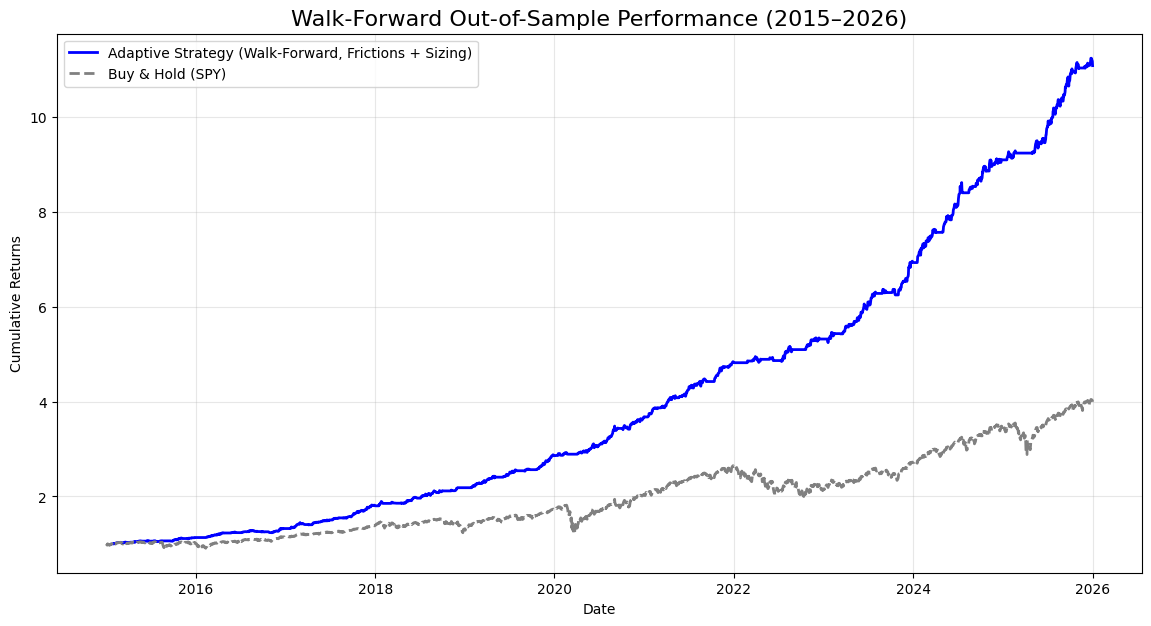

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

plt.plot(
    wf_test.index,
    wf_test['Cum_Strategy_Sized'],
    label='Adaptive Strategy (Walk-Forward, Frictions + Sizing)',
    color='blue',
    linewidth=2
)

plt.plot(
    wf_test.index,
    wf_test['Cum_BuyHold'],
    label='Buy & Hold (SPY)',
    color='gray',
    linestyle='--',
    linewidth=2
)

plt.title('Walk-Forward Out-of-Sample Performance (2015–2026)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()




Regime-map

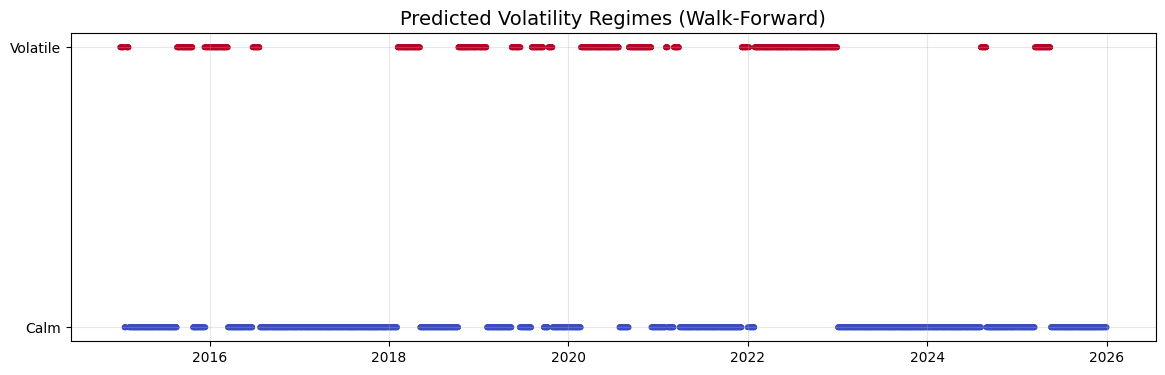

In [90]:
plt.figure(figsize=(14,4))

plt.scatter(
    wf_test.index,
    wf_test['Regime_Pred'],
    c=wf_test['Regime_Pred'],
    cmap='coolwarm',
    s=10
)

plt.title('Predicted Volatility Regimes (Walk-Forward)', fontsize=14)
plt.yticks([0,1], ['Calm','Volatile'])
plt.grid(True, alpha=0.3)

plt.show()


Overlay of strategy returns on regime map

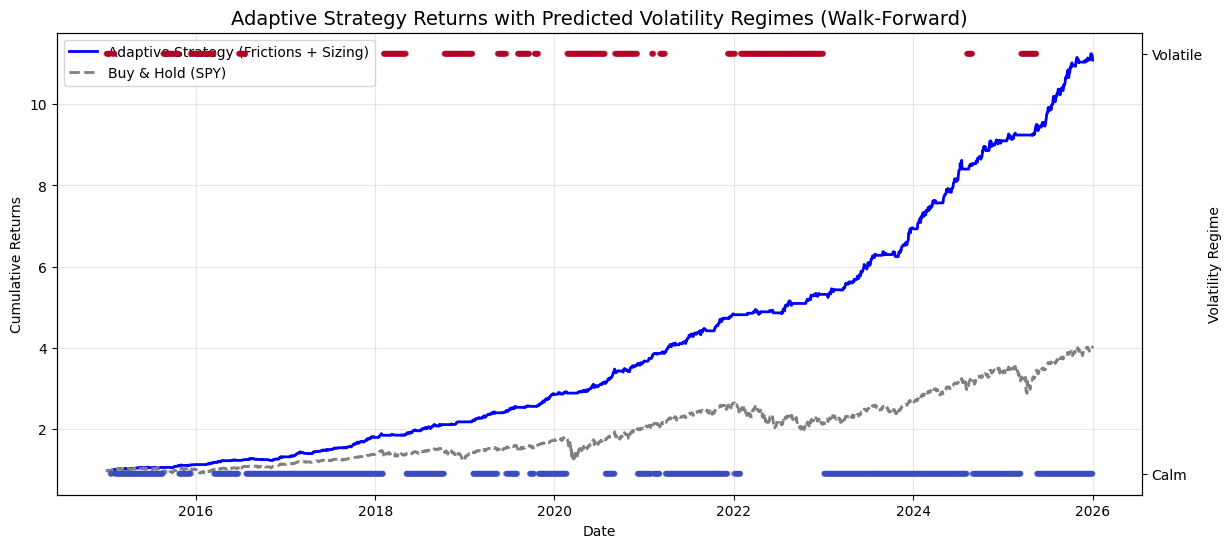

In [91]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14,6))

# --- Plot cumulative returns (strategy) ---
ax1.plot(
    wf_test.index,
    wf_test['Cum_Strategy_Sized'],
    color='blue',
    linewidth=2,
    label='Adaptive Strategy (Frictions + Sizing)'
)
ax1.plot(
    wf_test.index,
    wf_test['Cum_BuyHold'],
    color='gray',
    linestyle='--',
    linewidth=2,
    label='Buy & Hold (SPY)'
)

ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative Returns')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# --- Overlay volatility regimes ---
ax2 = ax1.twinx()
ax2.scatter(
    wf_test.index,
    wf_test['Regime_Pred'],
    c=wf_test['Regime_Pred'],
    cmap='coolwarm',
    s=10,
    alpha=0.4
)

ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Calm', 'Volatile'])
ax2.set_ylabel('Volatility Regime')

plt.title('Adaptive Strategy Returns with Predicted Volatility Regimes (Walk-Forward)', fontsize=14)
plt.show()


Metrics

In [92]:
import numpy as np

# --- Metrics for Walk-Forward Strategy ---

# Total years in walk-forward test
years = (wf_test.index[-1] - wf_test.index[0]).days / 365

# CAGR
cagr = wf_test['Cum_Strategy_Sized'].iloc[-1] ** (1/years) - 1

# Max Drawdown
rolling_max = wf_test['Cum_Strategy_Sized'].cummax()
drawdown = (wf_test['Cum_Strategy_Sized'] - rolling_max) / rolling_max
max_dd = drawdown.min()

# Sharpe Ratio
sharpe = np.sqrt(252) * wf_test['Strategy_Returns_Sized'].mean() / wf_test['Strategy_Returns_Sized'].std()

print(f"Walk-Forward CAGR (frictions + sizing): {cagr:.2%}")
print(f"Walk-Forward Max Drawdown (frictions + sizing): {max_dd:.2%}")
print(f"Walk-Forward Sharpe (frictions + sizing): {sharpe:.2f}")



Walk-Forward CAGR (frictions + sizing): 24.44%
Walk-Forward Max Drawdown (frictions + sizing): -3.77%
Walk-Forward Sharpe (frictions + sizing): 3.39


Sharpe ratio plot

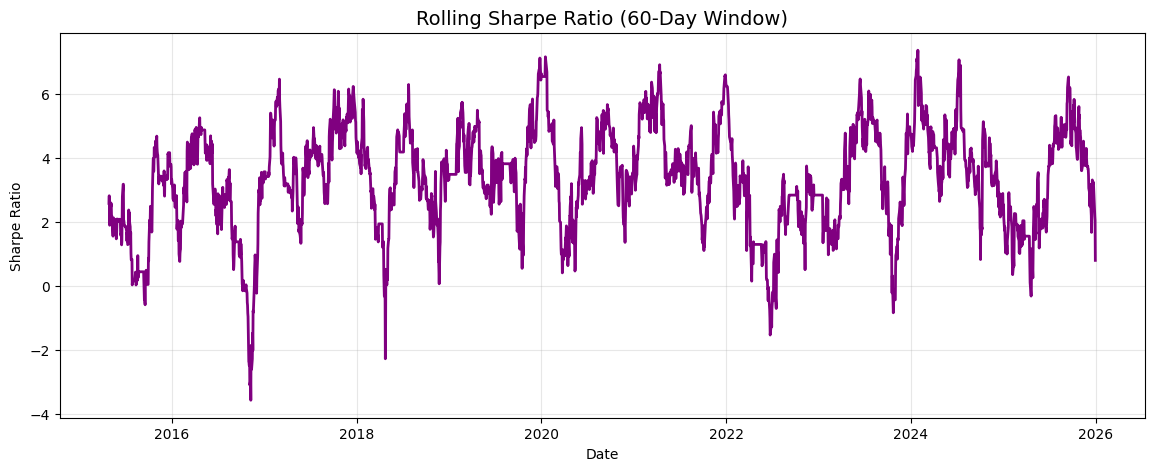

In [93]:
import matplotlib.pyplot as plt
import numpy as np

# --- Rolling Sharpe (60‑day window) ---
rolling_sharpe = (
    np.sqrt(252) *
    wf_test['Strategy_Returns_Sized'].rolling(60).mean() /
    wf_test['Strategy_Returns_Sized'].rolling(60).std()
)

plt.figure(figsize=(14,5))
plt.plot(rolling_sharpe, color='purple', linewidth=2)
plt.title('Rolling Sharpe Ratio (60‑Day Window)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.grid(True, alpha=0.3)
plt.show()


Drawdown plot

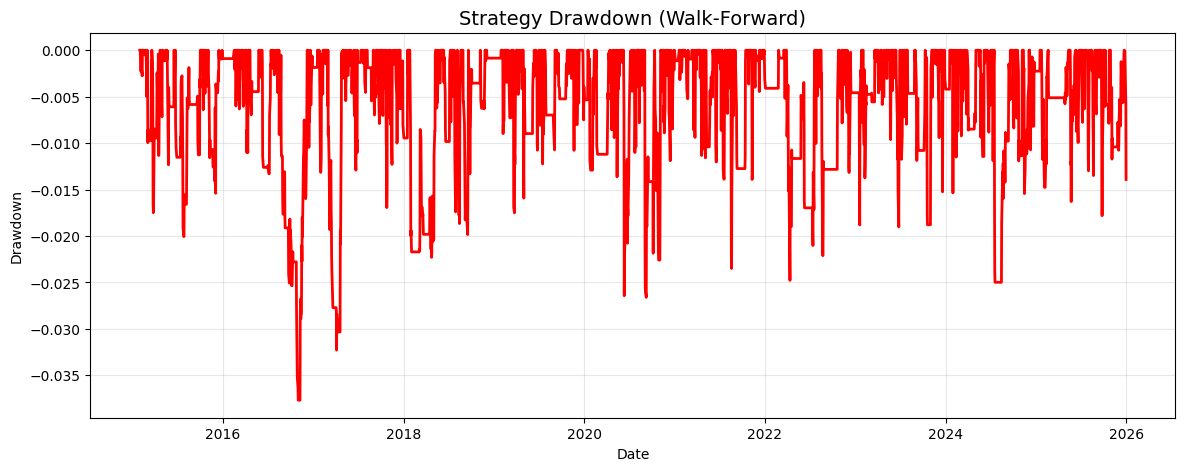

In [94]:
# --- Drawdown ---
cum = wf_test['Cum_Strategy_Sized']
rolling_max = cum.cummax()
drawdown = (cum - rolling_max) / rolling_max

plt.figure(figsize=(14,5))
plt.plot(drawdown, color='red', linewidth=2)
plt.title('Strategy Drawdown (Walk‑Forward)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.grid(True, alpha=0.3)
plt.show()
